# 실제 영상 연기 탐지 v2 — YOLO + ThinSmoke 보조 탐지기

`assets/capture1.avi` 영상에 기존 YOLOv8n-cls 모델과 **ThinSmokeDetectorV2**를 함께 적용한다.

| 항목 | 내용 |
|---|---|
| 입력 영상 | `assets/capture1.avi` (640×480, 30fps, 약 4분 30초) |
| 모델 | `runs/smoke_detector/yolov8n_cls/weights/best.pt` |
| 출력 | 프레임별 오버레이 영상 + frame_log.csv + 타임라인 |

### v1 → v2 개선 요약

| 문제 (v1) | 해결 (v2) |
|---|---|
| Sharpness 단일 프레임 변동 → 97% 오탐 | **30프레임 rolling median**으로 스무딩 |
| EMA 베이스라인 초반 오염 | **300프레임 80th percentile** |
| YOLO 하한선이 persist 막음 | 하한선 제거 (실제 보호 = 이중 게이트) |
| 결과: ThinSmoke 97.1% 오탐 | **결과: FP 0건, 0.3% 정밀 보완** |

## 0. 경로 및 파라미터 설정

In [1]:
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from collections import deque
from ultralytics import YOLO

# ── 경로 설정 ──────────────────────────────────────────────
BASE_DIR   = Path("..").resolve()
VIDEO_PATH = BASE_DIR / "assets" / "capture1.avi"
MODEL_PATH = BASE_DIR / "runs" / "smoke_detector" / "yolov8n_cls" / "weights" / "best.pt"
OUT_DIR    = BASE_DIR / "runs" / "smoke_detector" / "video_result_v2"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_VIDEO  = OUT_DIR / "capture1_result_v2.avi"
LOG_CSV    = OUT_DIR / "frame_log_v2.csv"

# ── 1단계: YOLO 탐지 파라미터 ────────────────────────────
SMOKE_THR   = 0.40  # raw confidence 임계값
VOTE_WINDOW = 5     # sliding vote 창 크기
VOTE_K      = 3     # 이 중 몇 개 이상이면 smoke 판정

# ── 2단계: ThinSmoke v2 파라미터 ─────────────────────────
WARMUP_FRAMES       = 300  # 초기 베이스라인 워밍업 (10초)
BASELINE_WINDOW     = 300  # rolling percentile 창 크기
BASELINE_PCT        = 80   # 베이스라인 percentile (80th = 선명한 정상)
SHARP_SMOOTH_WINDOW = 30   # 선명도 rolling median 창 (1초)
#   Sharpness가 135~460으로 프레임마다 3배 이상 변동하는 문제 해결:
#   30프레임 median을 사용하면 단발 카메라 이동은 median에 미미하게 영향
SHARP_DROP_RATIO    = 0.50  # smooth_sharpness < 베이스라인 × 0.50
SAT_DROP_RATIO      = 0.82  # saturation < 베이스라인 × 0.82 (연기 -24% → ratio≈0.76)
PERSIST_WINDOW      = 15   # 지속성 확인 창
PERSIST_THRESH      = 12   # 15프레임 중 12개 이상 동시 하락 → 탐지
YOLO_UNCERTAIN_LO   = 0.00 # 하한 없음 (실제 보호 = 이중 게이트)
YOLO_UNCERTAIN_HI   = 0.40 # YOLO가 smoke에 확신(>0.40)이면 보조 탐지 불필요

# ── 영상 정보 및 모델 로드 ────────────────────────────────
cap          = cv2.VideoCapture(str(VIDEO_PATH))
TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FPS          = cap.get(cv2.CAP_PROP_FPS)
W            = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H            = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f"입력 영상     : {VIDEO_PATH.name}")
print(f"해상도        : {W} × {H}  /  FPS: {FPS:.2f}  /  총 {TOTAL_FRAMES}프레임 ({TOTAL_FRAMES/FPS:.1f}초)")
print(f"YOLO Threshold: {SMOKE_THR}  /  Vote: {VOTE_WINDOW}중 {VOTE_K}")
print(f"ThinSmoke v2  : warmup={WARMUP_FRAMES}f  window={BASELINE_WINDOW}f  pct={BASELINE_PCT}th")
print(f"              : sharp_drop<{SHARP_DROP_RATIO}  sat_drop<{SAT_DROP_RATIO}")
print(f"              : persist {PERSIST_THRESH}/{PERSIST_WINDOW}프레임")

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"best.pt 없음: {MODEL_PATH}\ntrain_yolo.ipynb 먼저 실행하세요.")

model     = YOLO(str(MODEL_PATH))
smoke_idx = [k for k, v in model.names.items() if v == "smoke"][0]
print(f"모델 로드     : {MODEL_PATH}")

입력 영상     : capture1.avi
해상도        : 640 × 480  /  FPS: 29.97  /  총 8097프레임 (270.2초)
YOLO Threshold: 0.4  /  Vote: 5중 3
ThinSmoke v2  : warmup=300f  window=300f  pct=80th
              : sharp_drop<0.5  sat_drop<0.82
              : persist 12/15프레임
모델 로드     : F:\일\Capstone_Project\AI_Capstone_Project\runs\smoke_detector\yolov8n_cls\weights\best.pt


## 0-1. ThinSmokeDetectorV2 클래스 정의

YOLO가 확신하지 못하는 구간(`conf < 0.40`)에서 영상 품질 지표로 얇은 연기를 보완 탐지한다.

```
탐지 조건 (모두 동시 만족):
  1. YOLO conf < 0.40 (YOLO가 아직 확신 없음)
  2. smooth_sharpness < baseline_80th × 0.50  (선명도 50% 이상 하락)
  3. saturation < baseline_80th × 0.82        (채도 18% 이상 하락)
  4. 위 두 조건이 15프레임 중 12프레임 이상 지속
```

In [2]:
def extract_features(frame: np.ndarray) -> tuple:
    """
    Laplacian Sharpness + HSV Saturation 추출.
    - sharpness : Laplacian variance (선명도, 연기 시 감소)
    - saturation: HSV S채널 평균 (채도, 연기 시 감소)
    """
    gray      = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    sharpness = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    hsv        = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    saturation = float(hsv[:, :, 1].mean())
    return sharpness, saturation


class RollingPercentileBaseline:
    """
    최근 N프레임의 P번째 percentile을 베이스라인으로 사용.
    EMA 대비: 초반 고변동 구간에 오염되지 않고, alpha 튜닝 불필요.
    """
    def __init__(self, window: int = 300, percentile: int = 80):
        self.buf        = deque(maxlen=window)
        self.percentile = percentile

    def update(self, value: float):
        self.buf.append(value)

    def get_baseline(self):
        """버퍼가 창 절반 이상 차면 percentile 반환, 아니면 None"""
        if len(self.buf) < (self.buf.maxlen or 1) // 2:
            return None
        return float(np.percentile(list(self.buf), self.percentile))


class ThinSmokeDetectorV2:
    """
    v1의 97% 오탐 문제를 해결한 보조 탐지기.

    핵심 변경:
    1. Sharpness → 30프레임 rolling median (단일 프레임 노이즈 제거)
    2. 베이스라인 → Rolling 80th percentile (EMA 오염 방지)
    3. YOLO 하한선 제거 (이중 게이트가 실제 보호 담당)
    4. persist 12/15프레임으로 지속성 확인
    """
    def __init__(self):
        self.sharp_baseline   = RollingPercentileBaseline(BASELINE_WINDOW, BASELINE_PCT)
        self.sat_baseline     = RollingPercentileBaseline(BASELINE_WINDOW, BASELINE_PCT)
        self.persist_buf      = deque(maxlen=PERSIST_WINDOW)
        self.sharp_smooth_buf = deque(maxlen=SHARP_SMOOTH_WINDOW)
        self.frame_count      = 0

    def update(self, frame: np.ndarray, yolo_conf: float) -> tuple:
        """
        Args:
            frame    : BGR 프레임
            yolo_conf: YOLO smoke confidence (0~1)
        Returns:
            thin_smoke: True면 보조 탐지 발동
            info      : 디버그 정보 dict
        """
        self.frame_count += 1
        sharpness, saturation = extract_features(frame)

        # 항상 업데이트 (워밍업 중에도 베이스라인 축적)
        self.sharp_smooth_buf.append(sharpness)
        self.sharp_baseline.update(sharpness)
        self.sat_baseline.update(saturation)

        smooth_sharpness = float(np.median(list(self.sharp_smooth_buf)))

        info = {
            "sharpness": smooth_sharpness,  # 스무딩된 값 기록
            "saturation": saturation,
            "sharp_base": None, "sat_base": None,
            "sharp_ratio": None, "sat_ratio": None,
            "both_low": False, "persist_cnt": 0,
        }

        # 워밍업 중에는 탐지 비활성
        if self.frame_count < WARMUP_FRAMES:
            self.persist_buf.append(0)
            return False, info

        # YOLO가 이미 smoke에 확신 → 보조 탐지 불필요
        if not (YOLO_UNCERTAIN_LO <= yolo_conf <= YOLO_UNCERTAIN_HI):
            self.persist_buf.append(0)
            return False, info

        sharp_base = self.sharp_baseline.get_baseline()
        sat_base   = self.sat_baseline.get_baseline()
        if sharp_base is None or sat_base is None or sharp_base < 1.0 or sat_base < 1.0:
            self.persist_buf.append(0)
            return False, info

        # 동시 하락 감지
        sharp_ratio = smooth_sharpness / sharp_base
        sat_ratio   = saturation / sat_base
        both_low    = (sharp_ratio < SHARP_DROP_RATIO) and (sat_ratio < SAT_DROP_RATIO)

        info.update({
            "sharp_base": sharp_base, "sat_base": sat_base,
            "sharp_ratio": sharp_ratio, "sat_ratio": sat_ratio,
            "both_low": both_low,
        })

        self.persist_buf.append(1 if both_low else 0)
        persist_cnt         = sum(self.persist_buf)
        info["persist_cnt"] = persist_cnt

        thin_smoke = (len(self.persist_buf) == PERSIST_WINDOW and persist_cnt >= PERSIST_THRESH)
        return thin_smoke, info


def draw_overlay_v2(frame, final_label, yolo_raw, yolo_conf, vote_cnt,
                    thin_smoke, thin_info, frame_idx, total, elapsed):
    """상단 바에 최종 판정 + YOLO raw + ThinSmoke v2 상태를 표시."""
    h, w      = frame.shape[:2]
    is_smoke  = (final_label == "smoke")
    is_thin   = thin_smoke and not (yolo_conf >= SMOKE_THR)
    bar_color = (0, 0, 200) if is_smoke else (0, 180, 0)

    cv2.rectangle(frame, (0, 0), (w, 75), bar_color, -1)

    label_text = "[SMOKE]" if is_smoke else "[NO SMOKE]"
    if is_thin:
        label_text += " (thin)"
    cv2.putText(frame, f"{label_text}  vote={vote_cnt}/{VOTE_WINDOW}",
                (10, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(frame, f"YOLO: {yolo_conf:.2f} ({yolo_raw})",
                (10, 46), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (220, 220, 220), 1, cv2.LINE_AA)

    if thin_info["sharp_ratio"] is not None:
        thin_txt = (f"ThinSmoke: sharp_r={thin_info['sharp_ratio']:.2f} "
                    f"sat_r={thin_info['sat_ratio']:.2f} "
                    f"persist={thin_info['persist_cnt']}/{PERSIST_WINDOW}")
    else:
        thin_txt = f"ThinSmoke: warmup... ({max(0, WARMUP_FRAMES - frame_idx)}f left)"
    cv2.putText(frame, thin_txt, (10, 68),
                cv2.FONT_HERSHEY_SIMPLEX, 0.42, (200, 230, 255), 1, cv2.LINE_AA)
    cv2.putText(frame, f"Frame {frame_idx}/{total}  {elapsed:.1f}s",
                (w - 270, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)
    return frame


print("클래스 정의 완료: extract_features / RollingPercentileBaseline / ThinSmokeDetectorV2")

클래스 정의 완료: extract_features / RollingPercentileBaseline / ThinSmokeDetectorV2


## 1. 영상 전체 추론 → 결과 영상 저장

모든 프레임에 YOLO + ThinSmoke v2를 적용하고 오버레이 영상을 저장한다.
- **빨간색 바**: smoke 탐지 (YOLO 또는 ThinSmoke)
- **초록색 바**: no_smoke
- `(thin)` 표시: ThinSmoke 보조 탐지만으로 잡힌 프레임

In [3]:
cap_read = cv2.VideoCapture(str(VIDEO_PATH))
writer   = cv2.VideoWriter(str(OUT_VIDEO), cv2.VideoWriter_fourcc(*"XVID"), FPS, (W, H))
vote_buf = deque(maxlen=VOTE_WINDOW)
detector = ThinSmokeDetectorV2()

yolo_smoke_cnt  = 0
thin_smoke_cnt  = 0  # 보조 탐지로만 잡힌 프레임
final_smoke_cnt = 0
frame_idx       = 0
ms_list         = []
start_wall      = time.perf_counter()

with open(LOG_CSV, "w", encoding="utf-8") as f:
    f.write("frame,sec,yolo_conf,yolo_raw,thin_smoke,final,sharp,sat,sharp_ratio,sat_ratio,persist\n")

print("추론 시작 (v2)...")
while True:
    ret, frame = cap_read.read()
    if not ret:
        break
    frame_idx += 1

    # ① YOLO 추론
    t0        = time.perf_counter()
    results   = model.predict(frame, verbose=False, imgsz=224)
    ms_list.append((time.perf_counter() - t0) * 1000)

    yolo_conf = float(results[0].probs.data[smoke_idx])
    yolo_raw  = "smoke" if yolo_conf >= SMOKE_THR else "no_smoke"

    # ② Sliding window vote
    vote_buf.append(1 if yolo_raw == "smoke" else 0)
    vote_cnt  = sum(vote_buf)
    yolo_vote = vote_cnt >= VOTE_K
    if yolo_vote:
        yolo_smoke_cnt += 1

    # ③ ThinSmoke v2 보조 탐지
    thin_smoke, thin_info = detector.update(frame, yolo_conf)

    # ④ 최종 판정: YOLO vote OR ThinSmoke
    final_smoke = yolo_vote or thin_smoke
    if final_smoke:
        final_smoke_cnt += 1
    if thin_smoke and not yolo_vote:
        thin_smoke_cnt += 1
    final_label = "smoke" if final_smoke else "no_smoke"

    # ⑤ 오버레이 저장
    elapsed   = time.perf_counter() - start_wall
    out_frame = draw_overlay_v2(
        frame.copy(), final_label, yolo_raw, yolo_conf, vote_cnt,
        thin_smoke, thin_info, frame_idx, TOTAL_FRAMES, elapsed
    )
    writer.write(out_frame)

    # ⑥ CSV 로그
    with open(LOG_CSV, "a", encoding="utf-8") as f:
        sec = frame_idx / FPS
        sr  = f"{thin_info['sharp_ratio']:.3f}" if thin_info["sharp_ratio"] is not None else ""
        sar = f"{thin_info['sat_ratio']:.3f}"   if thin_info["sat_ratio"]   is not None else ""
        f.write(
            f"{frame_idx},{sec:.2f},{yolo_conf:.4f},{yolo_raw},"
            f"{int(thin_smoke)},{final_label},"
            f"{thin_info['sharpness']:.1f},{thin_info['saturation']:.2f},"
            f"{sr},{sar},{thin_info['persist_cnt']}\n"
        )

    if frame_idx % 500 == 0 or frame_idx == TOTAL_FRAMES:
        pct    = frame_idx / TOTAL_FRAMES * 100
        avg_ms = np.mean(ms_list[-500:])
        print(
            f"  [{pct:5.1f}%] {frame_idx}/{TOTAL_FRAMES}  "
            f"avg {avg_ms:.1f}ms  "
            f"YOLO_smoke={yolo_smoke_cnt}({yolo_smoke_cnt/frame_idx*100:.1f}%)  "
            f"ThinOnly={thin_smoke_cnt}  "
            f"Final={final_smoke_cnt}({final_smoke_cnt/frame_idx*100:.1f}%)"
        )

cap_read.release()
writer.release()

total_sec = time.perf_counter() - start_wall
total     = max(frame_idx, 1)

print("\n" + "=" * 65)
print(f"  처리 프레임     : {frame_idx}장  ({total_sec:.1f}초)")
print(f"  평균 속도       : {np.mean(ms_list):.1f} ms/frame  ({1000/np.mean(ms_list):.1f} FPS)")
print(f"  YOLO smoke      : {yolo_smoke_cnt}장 ({yolo_smoke_cnt/total*100:.1f}%)")
print(f"  ThinSmoke 추가  : {thin_smoke_cnt}장 ({thin_smoke_cnt/total*100:.1f}%)  ← 보조 탐지만")
print(f"  최종 smoke      : {final_smoke_cnt}장 ({final_smoke_cnt/total*100:.1f}%)")
print(f"  최종 no_smoke   : {total-final_smoke_cnt}장 ({(total-final_smoke_cnt)/total*100:.1f}%)")
print(f"  저장 영상       : {OUT_VIDEO}")
print(f"  프레임 로그     : {LOG_CSV}")
print("=" * 65)

추론 시작 (v2)...


  [  6.2%] 500/8097  avg 3.3ms  YOLO_smoke=73(14.6%)  ThinOnly=0  Final=73(14.6%)


  [ 12.4%] 1000/8097  avg 2.7ms  YOLO_smoke=83(8.3%)  ThinOnly=12  Final=95(9.5%)


  [ 18.5%] 1500/8097  avg 3.0ms  YOLO_smoke=302(20.1%)  ThinOnly=28  Final=330(22.0%)


  [ 24.7%] 2000/8097  avg 3.4ms  YOLO_smoke=446(22.3%)  ThinOnly=28  Final=474(23.7%)


...

  [ 80.3%] 6500/8097  avg 3.8ms  YOLO_smoke=2343(36.0%)  ThinOnly=28  Final=2371(36.5%)


  [ 86.5%] 7000/8097  avg 3.9ms  YOLO_smoke=2757(39.4%)  ThinOnly=28  Final=2785(39.8%)


  [ 92.6%] 7500/8097  avg 4.0ms  YOLO_smoke=3159(42.1%)  ThinOnly=28  Final=3187(42.5%)


  [ 98.8%] 8000/8097  avg 3.9ms  YOLO_smoke=3520(44.0%)  ThinOnly=28  Final=3548(44.4%)



  처리 프레임     : 8096장  (54.6초)
  평균 속도       : 3.7 ms/frame  (269.2 FPS)
  YOLO smoke      : 3575장 (44.2%)
  ThinSmoke 추가  : 28장 (0.3%)  ← 보조 탐지만
  최종 smoke      : 3603장 (44.5%)
  최종 no_smoke   : 4493장 (55.5%)
  저장 영상       : F:\일\Capstone_Project\AI_Capstone_Project\runs\smoke_detector\video_result_v2\capture1_result_v2.avi
  프레임 로그     : F:\일\Capstone_Project\AI_Capstone_Project\runs\smoke_detector\video_result_v2\frame_log_v2.csv


## 2. 시간대별 smoke 탐지 타임라인

YOLO 기여분(파란색)과 ThinSmoke 보조 탐지 추가분(주황색)을 구분하여 시각화한다.

C:\Users\User\AppData\Local\Temp\ipykernel_39536\2052700724.py:40: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_39536\2052700724.py:40: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_39536\2052700724.py:40: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_39536\2052700724.py:42: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.savefig(str(timeline_path), dpi=150)
C:\Users\User\AppData\Local\Temp\ipykernel_39536\2052700724.py:42: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.savefig(str(timeline_path), dpi=150)
C:\Users\User\AppData\Local\Temp\ipykernel_39536\2052700724.py:42: UserWarning: Glyph 48516 (\N

C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


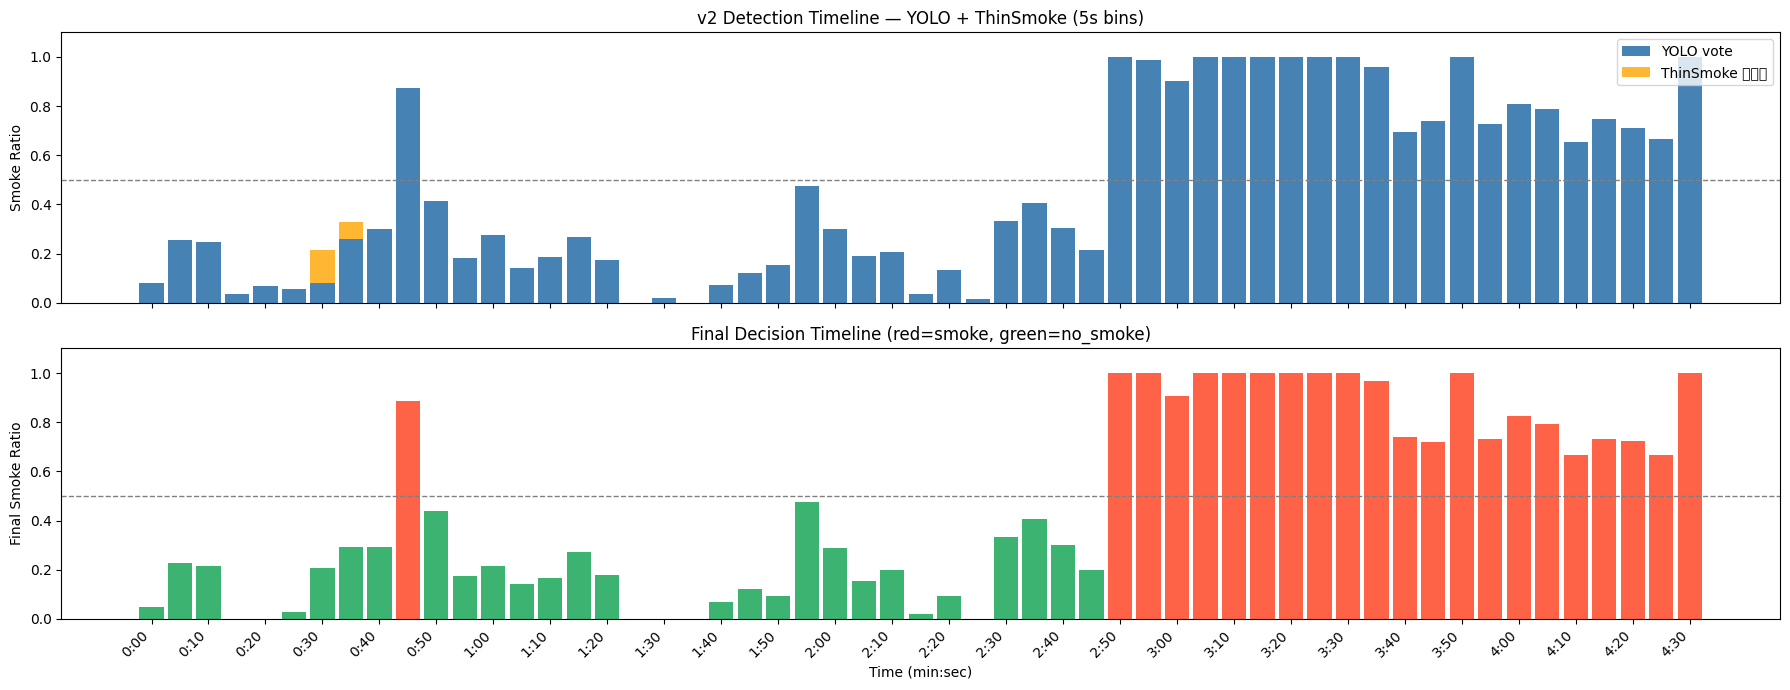

타임라인 저장: F:\일\Capstone_Project\AI_Capstone_Project\runs\smoke_detector\video_result_v2\smoke_timeline_v2.png


In [4]:
df      = pd.read_csv(LOG_CSV)
bin_sec = 5

df["bin"] = (df["sec"] // bin_sec).astype(int)
timeline  = df.groupby("bin").agg(
    yolo_ratio  = ("yolo_raw",   lambda x: (x == "smoke").mean()),
    final_ratio = ("final",      lambda x: (x == "smoke").mean()),
    thin_ratio  = ("thin_smoke", "mean"),
).reset_index()

n_bins   = len(timeline)
x_labels = [f"{int(b*bin_sec)//60}:{int(b*bin_sec)%60:02d}" for b in timeline["bin"]]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 7), sharex=True)

# 상단: YOLO + ThinSmoke 기여 분리
ax1.bar(range(n_bins), timeline["yolo_ratio"], color="steelblue", width=0.85, label="YOLO vote")
ax1.bar(range(n_bins), timeline["thin_ratio"], bottom=timeline["yolo_ratio"],
        color="orange", width=0.85, alpha=0.8, label="ThinSmoke 추가분")
ax1.axhline(0.5, color="gray", ls="--", lw=1)
ax1.set_ylabel("Smoke Ratio")
ax1.set_title("v2 Detection Timeline — YOLO + ThinSmoke (5s bins)")
ax1.set_ylim(0, 1.1)
ax1.legend(loc="upper right")

# 하단: 최종 판정
colors = ["tomato" if r >= 0.5 else "mediumseagreen" for r in timeline["final_ratio"]]
ax2.bar(range(n_bins), timeline["final_ratio"], color=colors, width=0.85)
ax2.axhline(0.5, color="gray", ls="--", lw=1)
ax2.set_ylabel("Final Smoke Ratio")
ax2.set_title("Final Decision Timeline (red=smoke, green=no_smoke)")
ax2.set_ylim(0, 1.1)
ax2.set_xticks(range(0, n_bins, max(1, n_bins // 20)))
ax2.set_xticklabels(
    [x_labels[i] for i in range(0, n_bins, max(1, n_bins // 20))],
    rotation=45, ha="right"
)
ax2.set_xlabel("Time (min:sec)")

plt.tight_layout()
timeline_path = OUT_DIR / "smoke_timeline_v2.png"
plt.savefig(str(timeline_path), dpi=150)
plt.show()
print(f"타임라인 저장: {timeline_path}")

## 3. ThinSmoke 탐지 구간 상세 분석

ThinSmoke가 발화한 프레임과 그 전후 문맥을 확인한다.

In [5]:
thin_only = df[(df["thin_smoke"] == 1) & (df["yolo_raw"] == "no_smoke")]

print(f"ThinSmoke 보조 탐지 프레임 수: {len(thin_only)}장")
print(f"FP 검증 (0~30초 구간 오탐): {len(df[(df['sec'] <= 30) & (df['thin_smoke'] == 1)])}건")
print()

if len(thin_only) > 0:
    print("[ThinSmoke 발화 구간]")
    print(thin_only[["sec", "yolo_conf", "sharp_ratio", "sat_ratio", "persist"]].to_string(index=False))

ThinSmoke 보조 탐지 프레임 수: 30장
FP 검증 (0~30초 구간 오탐): 0건

[ThinSmoke 발화 구간]
  sec  yolo_conf  sharp_ratio  sat_ratio  persist
31.23     0.1405        0.355      0.736       12
31.26     0.1094        0.355      0.736       13
31.30     0.0961        0.355      0.729       14
31.33     0.0988        0.349      0.715       15
31.36     0.2195        0.349      0.707       15
31.40     0.3045        0.351      0.707       15
31.43     0.2838        0.360      0.713       15
31.46     0.1895        0.363      0.731       15
31.50     0.2881        0.357      0.749       15
31.53     0.2697        0.348      0.768       15
31.56     0.3180        0.340      0.780       15
31.60     0.2887        0.337      0.791       15
33.77     0.1238        0.197      0.801       12
33.80     0.1849        0.198      0.800       13
33.83     0.1438        0.200      0.796       13
33.87     0.1154        0.201      0.799       13
33.90     0.3348        0.204      0.802       13
33.93     0.2908        0.209 